In [1]:
from torch import torch, nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import random
import numpy as np
from skimage.feature import hog
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:


isLocal = True
isColab = False

if isLocal:
    SAVE_PATH = './best_model_mlp.pth'
elif isColab:
    from google.colab import drive
    import os
    drive.mount('/content/drive', force_remount=True)
    os.chdir('/content/drive/MyDrive/MSAI/AI-600/assignment_02/')
    SAVE_PATH = '/content/drive/MyDrive/MSAI/AI-600/assignment_02/best_model_mlp.pth'



In [3]:
import os
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import random_split

def load_data():
    print(f"Current Working Directory: {os.getcwd()}")
    print(f"Files in this folder: {os.listdir('.')}")
    training_data = np.load('quickdraw_train.npz')
    testimgdata = np.load('quickdraw_test.npz')
    print(f"keys in training files:{training_data.files}")
    train_images = training_data['x_train']
    train_labels = training_data['y_train']
    class_names = training_data['class_names']
    print(f"keys in files:{testimgdata.files}")
    test_images = testimgdata['test_images']
    print(train_images.shape)
    print(train_labels.shape)
    print(len(class_names))
    print(test_images.shape)
    return train_images, train_labels, test_images

def prepare_data(x, y=None):
  images = torch.from_numpy(x).float()/255.0
  images = images.view(images.shape[0], 1, 28, 28)
  if len(images.shape) > 2:
    images = images.view(images.shape[0], -1)

  print(images.shape)
  if y is not None:
    labels = torch.from_numpy(y).long()
    print(labels.shape)
    print(labels[0])
    return TensorDataset(images, labels)
  else:
    return TensorDataset(images)



In [4]:
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

train_images, train_labels, test_images = load_data()

train_data = prepare_data(train_images, train_labels)
test_data = prepare_data(test_images)

generator = torch.Generator().manual_seed(42)
total_size = len(train_data)
train_size = int(0.8 * total_size)
val_size = total_size - train_size
train_data, val_data = random_split(train_data,
                                   [train_size, val_size],
                                    generator=generator)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)


print(f"Train size: {len(train_data)}")
print(f"Val size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

Device: cpu
Current Working Directory: d:\02-personal\01_ms ai\git-repo\600\assignment_02
Files in this folder: ['25280030_pa2.ipynb', '25280030_pa2_918612.ipynb', '25280030_pa2_exp.ipynb', '25280030_pa2_light.ipynb', '25280030_pa2_new.ipynb', '25280030_pa2_optimized_1.ipynb', 'best_model_mlp.pth', 'leaderboard_credentials', 'PA2_Deep_Learning (1).pdf', 'PA2_Deep_Learning.pdf', 'quickdraw_test.npz', 'quickdraw_train.npz', 'requirements.txt', 'venv']
keys in training files:['x_train', 'y_train', 'class_names']
keys in files:['test_images']
(60000, 784)
(60000,)
15
(15000, 784)
torch.Size([60000, 784])
torch.Size([60000])
tensor(0)
torch.Size([15000, 784])
Train size: 48000
Val size: 12000
Test size: 15000


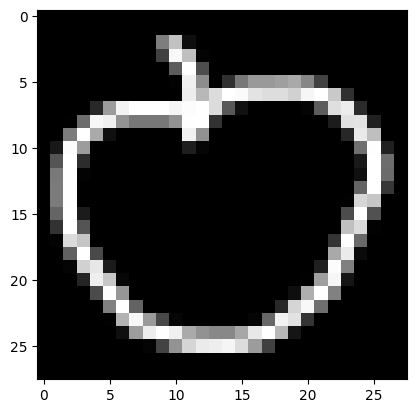

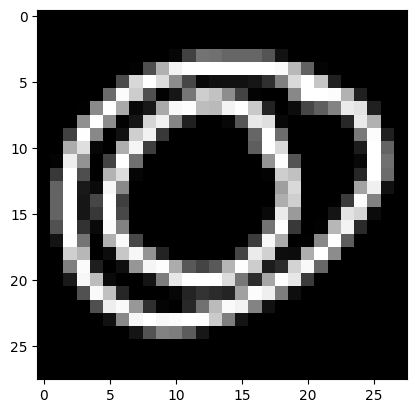

In [5]:
import matplotlib.pyplot as plt

img_tensor = torch.from_numpy(train_images[0])

img_tensor = img_tensor.view(1, 28, 28)
img_tensor = img_tensor.permute(1, 2, 0)
plt.imshow(img_tensor, cmap='gray')
plt.show()


img_tensor = torch.from_numpy(test_images[0])

img_tensor = img_tensor.view(1, 28, 28)
img_tensor = img_tensor.permute(1, 2, 0)
plt.imshow(img_tensor, cmap='gray')
plt.show()

In [6]:
HOG_PIXEL_PER_CELL = (4, 4)
HOG_CELL_PER_BLOCK = (2, 2)
HOG_ORIENTATIONS = 8

def get_hog_features(images_tensor):
  images_np = images_tensor.cpu().numpy()
  hog_features = []

  for image in images_np:
    image = image.reshape(28, 28)
    fd = hog(image,
             orientations=HOG_ORIENTATIONS,
             pixels_per_cell=HOG_PIXEL_PER_CELL,
             cells_per_block=HOG_CELL_PER_BLOCK, visualize=False)

    hog_features.append(fd)

  return torch.tensor(np.array(hog_features), dtype=torch.float32).to(DEVICE)

def calculate_hog_size(image_shape=(28, 28)):
  dummy_img = np.zeros(image_shape)
  fd = hog(dummy_img,
           orientations=HOG_ORIENTATIONS,
           pixels_per_cell=HOG_PIXEL_PER_CELL,
           cells_per_block=HOG_CELL_PER_BLOCK)

  return len(fd)

def apply_augmentation(images_tensor):

  images = images_tensor.view(-1, 1, 28, 28)
  augmented_image = []
  for i in range(images.shape[0]):
    img = images[i]

    angle = random.uniform(-15, 15)
    img = TF.rotate(img, angle)

    shift_x, shift_y = np.random.randint(-2,2), np.random.randint(-2,2)
    img = TF.affine(img, angle=0, translate=(shift_x, shift_y), scale=1.0, shear=0)

    augmented_image.append(img)

    images[i] = img

  return torch.stack(augmented_image).view(-1, 784)


In [7]:
class WideMLP(nn.Module):
  def __init__(self, input_size=784, num_class=15):
    super(WideMLP, self).__init__()
    self.fc1 = nn.Linear(input_size, 1048)
    self.fc2 = nn.Linear(1048, 1048)
    self.fc3 = nn.Linear(1048, num_class)

  def forward(self, x):
    x0 = x.view(-1, 784)
    x1 = F.relu(self.fc1(x0))
    x2 = F.relu(self.fc2(x1))
    y_hat = self.fc3(x2)
    return y_hat

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [8]:
class DeepMLP(nn.Module):
  def __init__(self, input_size=784, num_class=15):
    super(DeepMLP, self).__init__()
    self.input_size = input_size
    self.num_class = num_class
    self.fc1 = nn.Linear(self.input_size, 256)
    self.bn1 = nn.BatchNorm1d(256)

    self.fc2 = nn.Linear(256, 256)
    self.bn2 = nn.BatchNorm1d(256)

    self.fc3 = nn.Linear(256, 128)
    self.bn3 = nn.BatchNorm1d(128)

    self.fc4 = nn.Linear(128, 128)
    self.bn4 = nn.BatchNorm1d(128)

    # self.fc5 = nn.Linear(64, 32)
    # self.bn5 = nn.BatchNorm1d(32)

    self.fc6 = nn.Linear(128, self.num_class)

    self.drop_light = nn.Dropout(0.2)
    self.drop_heavy = nn.Dropout(0.4)

  def forward(self, x):
    # x = x.view(-1, 784)
    # print(x.shape)
    x = F.gelu(self.bn1(self.fc1(x)))
    x = self.drop_heavy(F.gelu(self.bn2(self.fc2(x))))
    x = self.drop_light(F.gelu(self.bn3(self.fc3(x))))
    x = F.gelu(self.bn4(self.fc4(x)))
    # x = F.gelu(self.bn5(self.fc5(x)))
    y_hat = self.fc6(x)
    return y_hat

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:
def get_gradients_norm(model):
    grad_norms = {}
    for name, p in model.named_parameters():
        if p.grad is not None:
            grad_norms[name] = p.grad.detach().data.norm(2).item()

    return grad_norms

In [10]:
def train_one_epoch(model, train_data, criterion, optimizer, grad_history=None):
    model.train()
    total_loss, accurate_predictions, sample_count = 0.0, 0, 0
    for images, labels in train_data:
      images = images.to(DEVICE)
      labels = labels.to(DEVICE)

      aug_images = apply_augmentation(images)
      hog_features = get_hog_features(aug_images)

      flat_aug = aug_images.view(-1, 784)
      images = torch.cat((flat_aug, hog_features), dim=1)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()


      norms = get_gradients_norm(model)
      for name, norm in norms.items():
          grad_history[name].append(norm)

      optimizer.step()

      total_loss += loss.item() * images.size(0)
      _, predicted_classes = torch.max(outputs.data, 1)
      accurate_predictions += (predicted_classes == labels).sum().item()
      sample_count += images.size(0)

    avg_loss = total_loss / sample_count
    accuracy =  100 * accurate_predictions / sample_count

    return avg_loss, accuracy

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, accurate_predictions, sample_count = 0.0, 0, 0
    with torch.no_grad():
      for images, labels in loader:
          images = images.to(DEVICE)
          labels = labels.to(DEVICE)

          hog_features = get_hog_features(images)
          flat_images = images.view(-1, 784)
          images = torch.cat((flat_images, hog_features), dim=1)

          outputs = model(images)
          loss = criterion(outputs, labels)

          _, predicted_classes = torch.max(outputs, 1)

          accurate_predictions += (predicted_classes == labels).sum().item()
          total_loss += loss.item() * images.size(0)
          sample_count += images.size(0)

    avg_loss = total_loss / sample_count
    accuracy =  100 * accurate_predictions / sample_count

    return avg_loss, accuracy



In [11]:
def confusion_mat(model, loader):
  model.eval()
  all_preds, all_labels = [], []

  with torch.no_grad():
      for images, labels in val_loader:
          images = images.to(DEVICE)
          labels = labels.to(DEVICE)
          hog_features = get_hog_features(images)
          flat_images = images.view(-1, 784)
          images = torch.cat((flat_images, hog_features), dim=1)

          outputs = model(images.to(DEVICE))
          all_preds.extend(outputs.argmax(1).cpu().numpy())
          all_labels.extend(labels.numpy())

  cm = confusion_matrix(all_labels, all_preds)
  plt.figure(figsize=(10,8))
  sns.heatmap(cm, annot=True, fmt='d')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()


In [12]:
import copy
from sklearn.metrics import confusion_matrix
import seaborn as sns
best_model_weights = None

def train_model(model:nn.Module, epochs = 40, learning_rate=0.001, weight_decay=1e-3, grad_history=None):
  print(f"Training model for {epochs} epochs")
  print(f"Learning rate: {learning_rate}")
  print(f"Weight Decay: {weight_decay}")


  best_val_loss = float('inf')
  train_losses, train_accs, val_losses, val_accs = [], [], [], []

  criterion_cel = nn.CrossEntropyLoss(label_smoothing=0.1)

  optimizer_adam = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # best working so far
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, mode='min', factor=0.3, patience=3, threshold=1e-3)

  for epoch in range(0, epochs):
    train_loss, train_acc = train_one_epoch(model=model,
                                            train_data=train_loader,
                                            criterion=criterion_cel,
                                            optimizer=optimizer_adam,
                                            grad_history=grad_history)

    val_loss, val_acc = evaluate(model, val_loader, criterion=criterion_cel)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_model_weights = copy.deepcopy(model.state_dict())
      torch.save(best_model_weights, SAVE_PATH)
      print(f"---> Best model updated at Epoch: {epoch+1} (Validation Loss: {val_loss:.4f})")

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_learning_rate = optimizer_adam.param_groups[0]['lr']

    print(f"Epoch: {epoch+1} (Learning Rate: {current_learning_rate:.6f})")

    scheduler.step(val_loss)
    print(f"Epoch: {epoch+1}) Training Loss: {train_loss:.4f} Training Accuracy: {train_acc:.2f}% Validation Loss {val_loss:.2f}% Validaion Accuracy:{val_acc:.2f}%")

  model.load_state_dict(best_model_weights)
  torch.save(model.state_dict(), SAVE_PATH)
  print("Training complete. Loaded best model weights")
  print(f"Best model saved at {SAVE_PATH}")
  confusion_mat(model, val_loader)

  return train_losses, train_accs, val_losses, val_accs


In [13]:
# # Initialize Wide model
# wide_model = WideMLP().to(DEVICE)
# print(f"WideMLP Parameters: {count_parameters(wide_model)}")

# EPOCHS = 20
# LEARNING_RATE = 0.0005
# L2_REGULARIZATION = 1e-3
# train_losses, train_acc, val_losses, val_acc = train_model(wide_model, epochs=EPOCHS, learning_rate=L2_REGULARIZATION)

# plt.figure(figsize=(15, 5))
# plt.subplot(1, 2, 1)
# plt.plot(train_losses, label='Training Loss', color='#1f77b4')
# plt.plot(val_losses, label='Validation Loss', color='#1f7f0e')
# plt.title('Wide MLP Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(train_acc, label='Training Acc', color='#1f77b4')
# plt.plot(val_acc, label='Validation Acc', color='#1f7f0e')
# plt.title('Wide MLP Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()

# plt.tight_layout()
# plt.show()



In [ ]:
# Initialize Wide model
# Initialize model

input_size = calculate_hog_size() + 784
print(input_size)
deep_model = DeepMLP(input_size).to(DEVICE)
print(f"DeepMLP Parameters: {count_parameters(deep_model)}")

EPOCHS = 40
LEARNING_RATE = 1e-4
L2_REGULARIZATION = 1e-4
WEIGHTS_DECAY = 3e-4
grad_history = {name:[] for name, _ in deep_model.named_parameters()}
train_losses, train_acc, val_losses, val_acc = train_model(deep_model, epochs=EPOCHS, learning_rate=LEARNING_RATE, weight_decay=WEIGHTS_DECAY, grad_history=grad_history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='#1f77b4')
plt.plot(val_losses, label='Validation Loss', color='#1f7f0e')
plt.title('Deep MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Acc', color='#1f77b4')
plt.plot(val_acc, label='Validation Acc', color='#1f7f0e')
plt.title('Deep MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

1936
DeepMLP Parameters: 614543
Training model for 40 epochs
Learning rate: 0.0001
Weight Decay: 0.0003
---> Best model updated at Epoch: 1 (Validation Loss: 1.2197)
Epoch: 1 (Learning Rate: 0.000100)
Epoch: 1) Training Loss: 1.7730 Training Accuracy: 53.58% Validation Loss 1.22% Validaion Accuracy:74.84%
---> Best model updated at Epoch: 2 (Validation Loss: 1.0933)
Epoch: 2 (Learning Rate: 0.000100)
Epoch: 2) Training Loss: 1.3165 Training Accuracy: 70.05% Validation Loss 1.09% Validaion Accuracy:78.58%
---> Best model updated at Epoch: 3 (Validation Loss: 1.0509)
Epoch: 3 (Learning Rate: 0.000100)
Epoch: 3) Training Loss: 1.2337 Training Accuracy: 72.90% Validation Loss 1.05% Validaion Accuracy:80.53%
---> Best model updated at Epoch: 4 (Validation Loss: 1.0255)
Epoch: 4 (Learning Rate: 0.000100)
Epoch: 4) Training Loss: 1.1909 Training Accuracy: 74.65% Validation Loss 1.03% Validaion Accuracy:81.37%
---> Best model updated at Epoch: 5 (Validation Loss: 1.0067)
Epoch: 5 (Learning Rat

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for name, grads in grad_history.items():
    if 'weight' in name: # Focus on weights, ignore biases for clarity
        plt.plot(grads, label=name)

plt.title("Gradient Magnitudes per Layer")
plt.xlabel("Iterations")
plt.ylabel("L2 Norm of Gradient")
plt.legend()
plt.yscale('log') # Use log scale because magnitudes vary wildly
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_gradient_zoom(grad_history, layer_name='fc1.weight', limit=100):
    data = grad_history[layer_name][:limit]

    plt.figure(figsize=(12, 5))
    # Plotting with markers to see individual iterations
    plt.plot(data, marker='o', linestyle='-', markersize=4, color='#1f77b4', alpha=0.7)

    plt.title(f"Micro-View: Gradient Magnitude for {layer_name} (First {limit} Iterations)")
    plt.xlabel("Iteration (Step-by-Step)")
    plt.ylabel("Gradient Norm (L2)")
    plt.grid(True, alpha=0.3)

    # Annotate the "Start" and "End" of this window
    plt.annotate('Initial Shock', xy=(0, data[0]), xytext=(10, data[0]+0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.show()

# Run this to see the "DNA" of your model's learning
plot_gradient_zoom(grad_history)

In [ ]:
def run_predictions(model, loader):
  print(f"Evaluation on Test Set:")

  all_predictions = []
  model.eval()
  with torch.no_grad():
    for batch in loader:
      images = batch[0].to(DEVICE)
      # images = images.to(DEVICE)

      hog_features = get_hog_features(images)
      flat_images = images.view(-1, 784)
      images = torch.cat((flat_images, hog_features), dim=1)

      outputs = model(images)
      _, predictions = torch.max(outputs, 1)
      all_predictions.extend(predictions.cpu().numpy().tolist())

  return all_predictions


predictions = run_predictions(deep_model, test_loader)
predictions_string = ",".join(map(str, predictions))

output_file = "predictions.txt"

with open(output_file, "w") as f:
    f.write(predictions_string)

print(f"Predictions saved to {output_file}")


In [ ]:
import copy
from sklearn.metrics import confusion_matrix
import seaborn as sns
best_model_weights = None

def train_model(model:nn.Module, epochs = 40, learning_rate=0.001, weight_decay=1e-3, grad_history=None. swa_start= 0):
  print(f"Training model for {epochs} epochs")
  print(f"Learning rate: {learning_rate}")
  print(f"Weight Decay: {weight_decay}")


  best_val_loss = float('inf')
  train_losses, train_accs, val_losses, val_accs = [], [], [], []

  criterion_cel = nn.CrossEntropyLoss(label_smoothing=0.07)

  optimizer_adam = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # best working so far
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, mode='min', factor=0.3, patience=3, threshold=1e-3)

  swa_model = optim.swa_utils.AveragedModel(model)
  swa_scheduler = None
  if swa_start > 0:
    swa_scheduler = optim.swa_utils.SWALR(optimizer_adam, swa_lr=5e-5)

  for epoch in range(0, epochs):
    train_loss, train_acc = train_one_epoch(model=model,
                                            train_data=train_loader,
                                            criterion=criterion_cel,
                                            optimizer=optimizer_adam,
                                            grad_history=grad_history)

    val_loss, val_acc = evaluate(model, val_loader, criterion=criterion_cel)

    if swa_start > 0 and epoch >= swa_start:
      swa_model.update_parameters(optimizer_adam)
      swa_scheduler.step()
    else:
      scheduler.step(val_loss)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_model_weights = copy.deepcopy(model.state_dict())
      torch.save(best_model_weights, SAVE_PATH)
      print(f"---> Best model updated at Epoch: {epoch+1} (Validation Loss: {val_loss:.4f})")

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_learning_rate = optimizer_adam.param_groups[0]['lr']

    print(f"Epoch: {epoch+1} (Learning Rate: {current_learning_rate:.6f})")

    scheduler.step(val_loss)
    print(f"Epoch: {epoch+1}) Training Loss: {train_loss:.4f} Training Accuracy: {train_acc:.2f}% Validation Loss {val_loss:.2f}% Validaion Accuracy:{val_acc:.2f}%")

  if swa_start > 0:
    print("Finailizing SWA: updating the Batch Normalized stats")
    torch.optim.swa_utils.update_bn(train_loader, swa_model)
    print("Updating the parameters")
    model =  swa_model.module
    best_model_weights = model.state_dict()
  
  model.load_state_dict(best_model_weights)
  torch.save(model.state_dict(), SAVE_PATH)
  print("Training complete. Loaded best model weights")
  print(f"Best model saved at {SAVE_PATH}")
  confusion_mat(model, val_loader)

  return train_losses, train_accs, val_losses, val_accs
